In [1]:
from datasets import load_dataset

dataset = load_dataset("google-research-datasets/go_emotions", "simplified")

print(dataset)
print(dataset['train'][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}


In [2]:
import pandas as pd

train_df = pd.DataFrame(dataset['train'])
print(f"Training samples: {len(train_df)}")
print(f"Columns: {train_df.columns.tolist()}")
print(f"\nFirst few rows:")
train_df.head()

Training samples: 43410
Columns: ['text', 'labels', 'id']

First few rows:


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


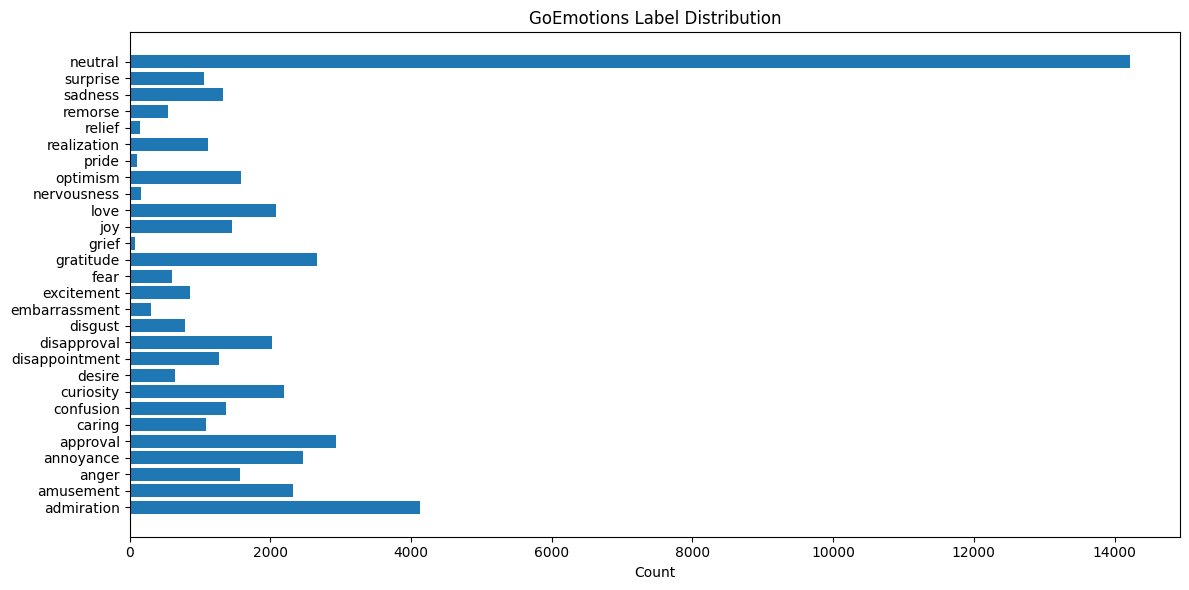

In [3]:
import matplotlib.pyplot as plt

# GoEmotions has 28 labels (27 emotions + neutral)
emotion_labels = dataset['train'].features['labels'].feature.names

# Count each label (each sample can have multiple labels)
from collections import Counter
label_counts = Counter()
for example in dataset['train']:
    for label in example['labels']:
        label_counts[label] += 1

# Map indices to names and plot
label_names = [emotion_labels[i] for i in sorted(label_counts.keys())]
counts = [label_counts[i] for i in sorted(label_counts.keys())]

plt.figure(figsize=(12, 6))
plt.barh(label_names, counts)
plt.xlabel('Count')
plt.title('GoEmotions Label Distribution')
plt.tight_layout()
plt.savefig('label_distribution.png')
plt.show()